# Lista III

## Regularyzacja zadanie na 3.0

Celem jest porownanie modeli bazowych z wersjami regularyzowanymi oraz znalezienie punktu, w ktorym model przestaje sie nadmiernie dopasowywac do zbioru treningowego.

## Przygotowanie danych

In [5]:

from algorithms.regularization.linear_regularization_comparison import LinearRegularizationComparison
from algorithms.regularization.tree_regularization import TreeRegularizationComparison
from experiments.reporting import (
    show_linear_regularization_report,
    show_sweet_spot_report,
    show_tree_regularization_report,
)
from utils.file_operations import (
    load_diamonds_data,
    load_telco_data,
    split_diamonds_data,
    split_telco_data,
)
from utils.preprocessing import (
    encode_train_test_features,
    prepare_diamonds_data,
    prepare_linear_regularization_data,
    prepare_telco_data,
)

train_diamonds, test_diamonds = split_diamonds_data(load_diamonds_data())
train_telco, test_telco = split_telco_data(load_telco_data())

X_train_diamonds, y_train_diamonds, X_test_diamonds, y_test_diamonds = prepare_diamonds_data(
    train_diamonds, test_diamonds
)
X_train_telco, y_train_telco, X_test_telco, y_test_telco = prepare_telco_data(
    train_telco, test_telco
)

linear_data = prepare_linear_regularization_data(
    X_train_diamonds, y_train_diamonds, X_test_diamonds, y_test_diamonds
)
X_train_telco_encoded, X_test_telco_encoded = encode_train_test_features(X_train_telco, X_test_telco)

## Lasso i Ridge

Modele liniowe sa trenowane wlasna implementacja Gradient Descent. Lasso uzywa kary L1, ktora moze wyzerowac wagi, a Ridge uzywa kary L2, ktora zmniejsza wartosci wag bez ich zerowania. Jako celowo przeregulowany model bazowy uzywam regresji wielomianowej stopnia 20 dla cechy `carat`.

,model_type,alpha,train_mse,test_mse,nonzero_weights,zero_weights,mean_abs_weight,max_abs_weight
0,Ridge,0.0000,1.994212e+06,2.454371e+06,20,0,0.1279,0.5899
1,Ridge,0.0000,1.994212e+06,2.454368e+06,20,0,0.1279,0.5899
2,Ridge,0.0000,1.994213e+06,2.454346e+06,20,0,0.1279,0.5898
3,Ridge,0.0000,1.994224e+06,2.454124e+06,20,0,0.1279,0.5897
4,Ridge,0.0001,1.994329e+06,2.451914e+06,20,0,0.1277,0.5886
5,Ridge,0.0010,1.995426e+06,2.430902e+06,20,0,0.1256,0.5779
6,Ridge,0.0100,2.008515e+06,2.297831e+06,20,0,0.1101,0.4997
7,Ridge,0.1000,2.155671e+06,2.310426e+06,20,0,0.0666,0.4930
8,Ridge,1.0000,3.558118e+06,3.946459e+06,20,0,0.0466,0.2741
9,Ridge,10.0000,1.042571e+07,1.075905e+07,20,0,0.0140,0.0721


,model_type,alpha,train_mse,test_mse,nonzero_weights,zero_weights,mean_abs_weight,max_abs_weight
0,Lasso,0.0032,2.011448e+06,2.209420e+06,15,5,0.0894,0.5939
1,Ridge,0.0100,2.008515e+06,2.297831e+06,20,0,0.1101,0.4997


,model,train_mse,test_mse,zero_weights
0,baseline GD,1994212.09,2454370.89,0
1,Ridge alpha=1e-02,2008515.19,2297831.08,0
2,Lasso alpha=3e-03,2011448.45,2209419.52,5


,feature,baseline_abs_weight,ridge_abs_weight,lasso_abs_weight,lasso_zero
0,carat,0.4262,0.4846,0.4748,False
1,carat^2,0.5899,0.4997,0.5939,False
2,carat^3,0.2103,0.1727,0.0490,False
3,carat^4,0.1844,0.1366,0.1225,False
4,carat^5,0.2812,0.2161,0.2292,False
5,carat^6,0.2052,0.1629,0.0927,False
6,carat^7,0.1103,0.0923,0.0000,True
7,carat^8,0.0417,0.0395,0.0000,True
8,carat^9,0.0004,0.0058,0.0000,True
9,carat^10,0.0244,0.0144,0.0000,True


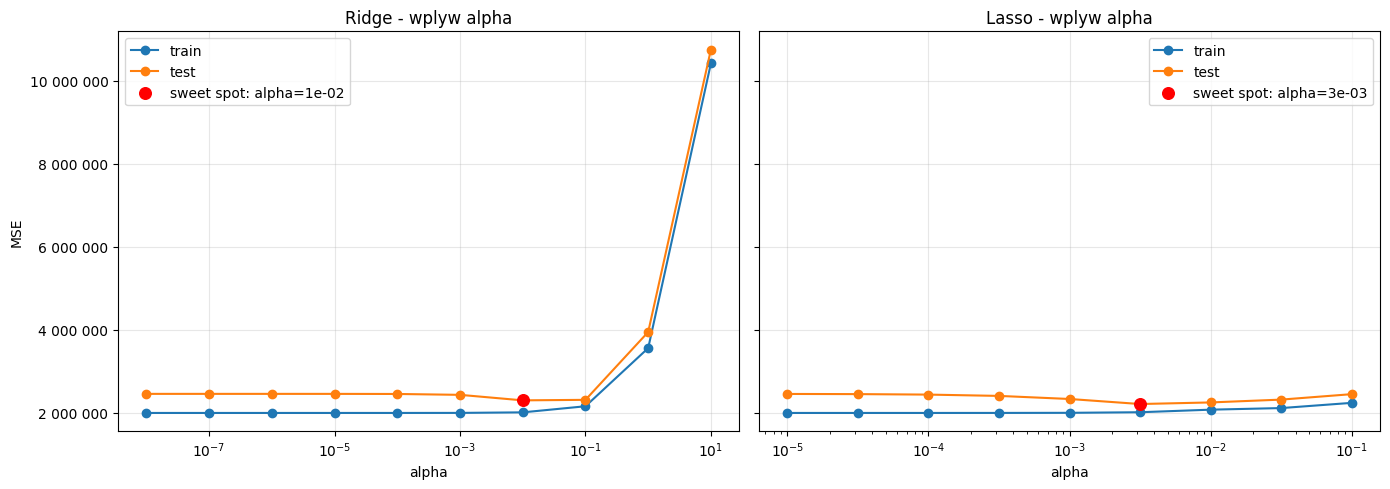

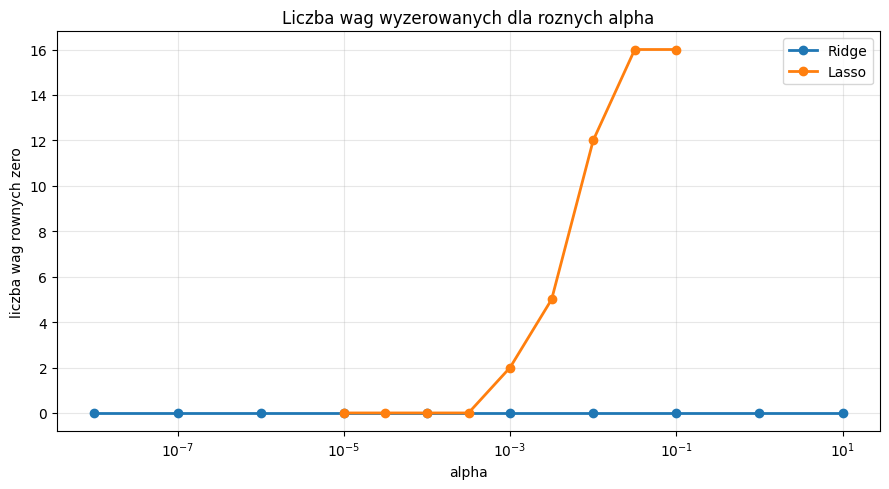

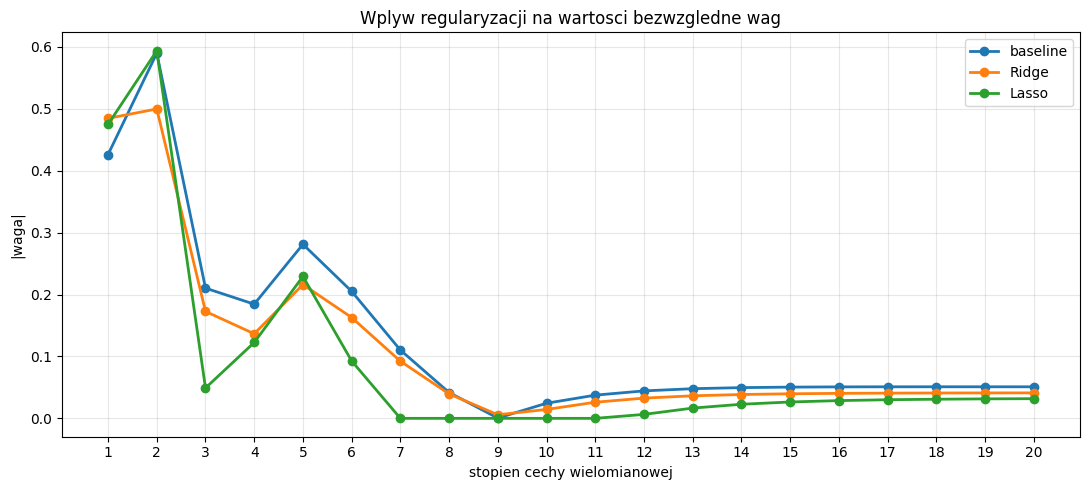

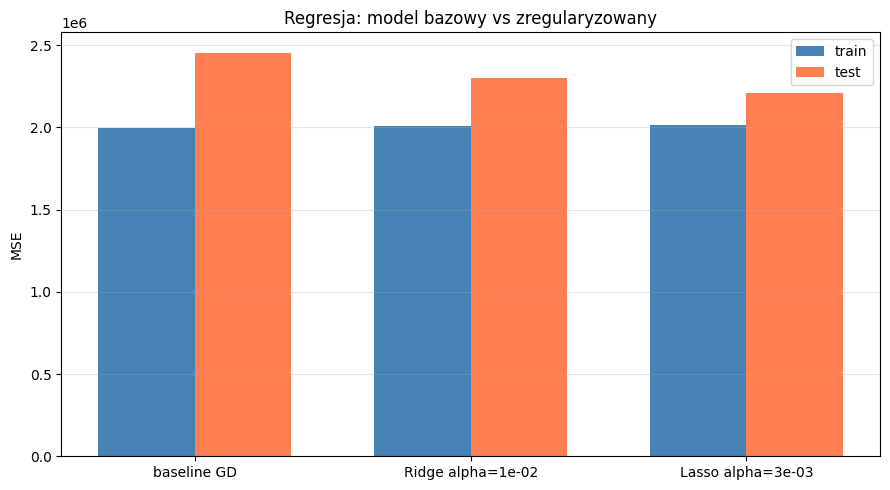

In [6]:
linear_experiment = LinearRegularizationComparison().compare(**linear_data)
show_linear_regularization_report(linear_experiment)

Wyniki pokazuja dwa efekty regularyzacji: Ridge zmniejsza bezwzgledne wartosci wag, ale ich nie zeruje, natomiast Lasso zeruje czesc wag i dziala jak selektor cech. Najlepsza wersja regularyzowana ma nizszy blad testowy niz model bazowy.

## Regularyzacja drzewa decyzyjnego

Drzewo bazowe nie ma ograniczen strukturalnych i mocno dopasowuje sie do danych treningowych. Ponizej badam wplyw `min_samples_split`, `min_samples_leaf` i `max_features`.

,parameter,value,label,is_default,train_error,test_error
0,min_samples_split,2,2,True,0.0020,0.2711
1,min_samples_split,5,5,False,0.0410,0.2725
2,min_samples_split,10,10,False,0.0788,0.2654
3,min_samples_split,20,20,False,0.1141,0.2463
4,min_samples_split,40,40,False,0.1479,0.2314
5,min_samples_split,80,80,False,0.1690,0.2207
6,min_samples_split,120,120,False,0.1823,0.2129
7,min_samples_split,200,200,False,0.1919,0.1994
8,min_samples_split,400,400,False,0.1972,0.2016
9,min_samples_leaf,1,1,True,0.0020,0.2711


,parameter,value,label,is_default,train_error,test_error
0,min_samples_split,200,200,False,0.1919,0.1994
1,min_samples_leaf,120,120,False,0.1972,0.2016
2,max_features,None,None,True,0.0020,0.2711


,model,train_error,test_error
0,baseline tree,0.0020,0.2711
1,min_samples_split=200,0.1919,0.1994


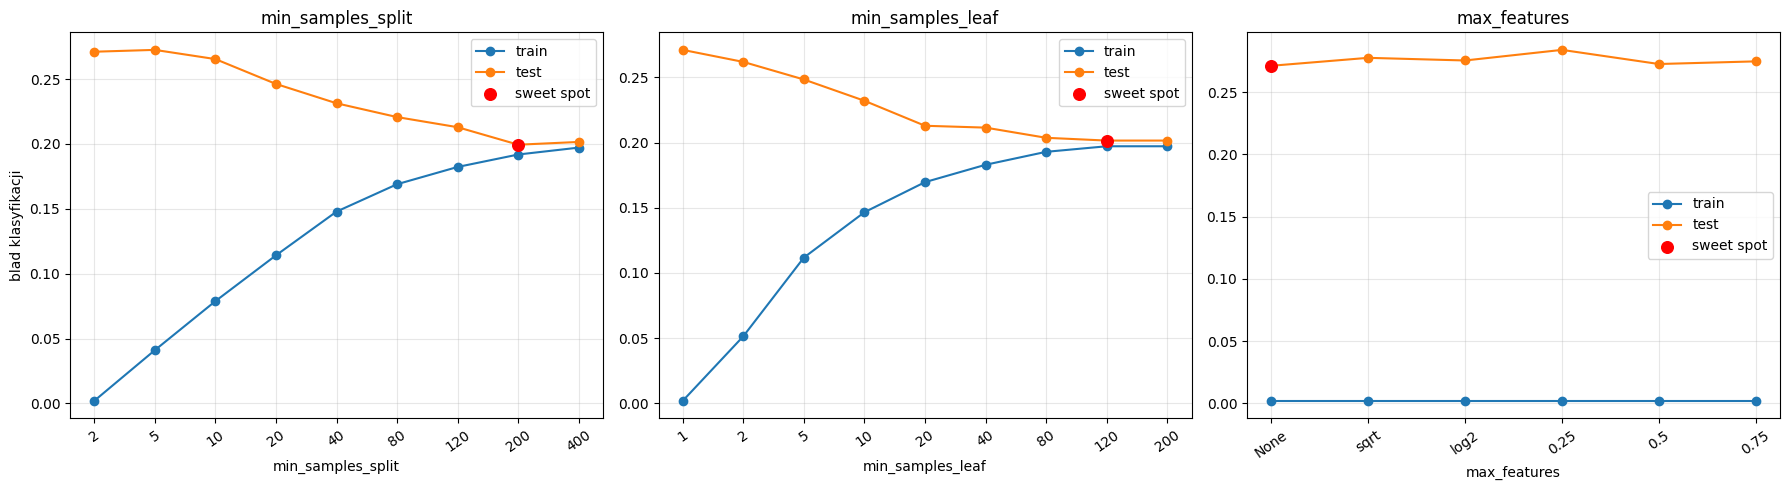

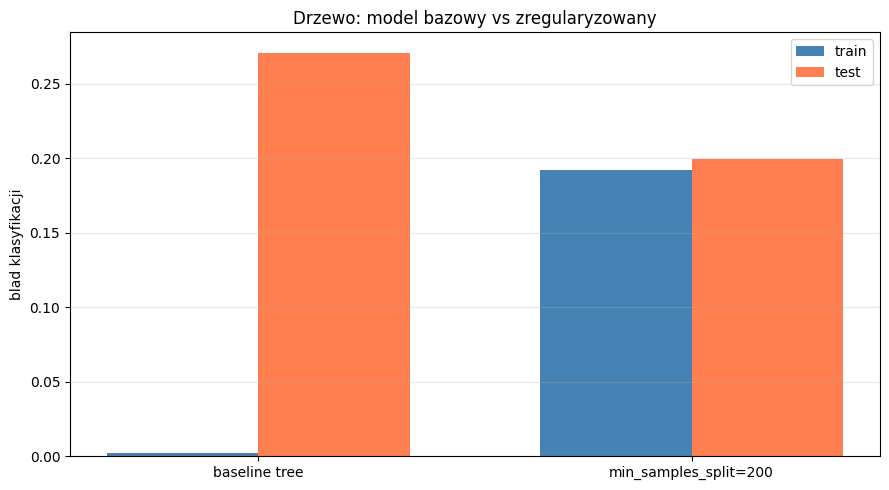

,task,baseline_model,regularized_model,baseline_test_metric,regularized_test_metric,improvement
0,regression,baseline GD,Lasso alpha=3e-03,2.454371e+06,2.209420e+06,244951.3724
1,classification,baseline tree,min_samples_split=200,2.711000e-01,1.994000e-01,0.0717


In [7]:
tree_experiment = TreeRegularizationComparison().compare(
    X_train_telco_encoded, y_train_telco, X_test_telco_encoded, y_test_telco
)
show_tree_regularization_report(tree_experiment)
show_sweet_spot_report(linear_experiment, tree_experiment)

Najlepszy punkt dla drzewa znajduje sie przy wiekszym wymaganiu minimalnej liczby probek w wezle. Model bazowy ma bardzo niski blad treningowy, ale wyzszy blad testowy, co wskazuje na overfitting. Po regularyzacji blad testowy spada, mimo ze blad treningowy rosnie.

## Zadanie na 3.5
## Porównanie DecisionTree i RandomForrest



,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.728886,0.731692,0.728886,0.730236
1,Random Forest,0.777857,0.765484,0.777857,0.768824
2,Bagging,0.779986,0.769958,0.779986,0.773243


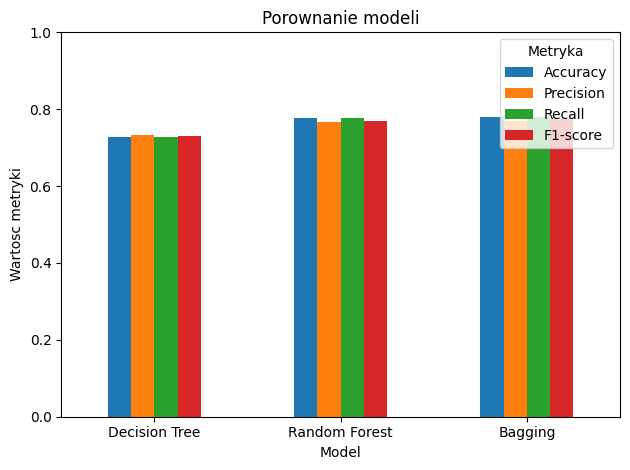

In [8]:
from algorithms.bagging.tree_comparisions import ClassificationComparison
from plots.plots import plot_classification_model_comparison

decision_vs_random = ClassificationComparison()
result = decision_vs_random.compare(
    X_train=X_train_telco_encoded,
    X_test=X_test_telco_encoded,
    y_train=y_train_telco,
    y_test=y_test_telco,
)
comparison_df = decision_vs_random.build_comparison_df(result)
display(comparison_df)
plot_classification_model_comparison(result)